# Défi ÉquiAlgo : rapport d'audit

Ce carnet mesure le biais du comité historique et du modèle en production, identifie les
variables proxys, justifie la métrique d'équité retenue et compare le modèle en production
à notre modèle corrigé (`model_corrige.py`).

**Ce qu'on démontre :**

1. **Le biais est direct.** À cote R égale, un dossier d'une région éloignée a beaucoup moins
   de chances d'obtenir la bourse. Sur les 21 points d'écart, environ **5** s'expliquent par le
   profil des candidats et environ **16** ne s'expliquent pas.
2. **La pénalité vaut environ 1,4 point de cote R.** C'est ce que le comité retire, en moyenne, aux
   dossiers des régions éloignées.
3. **Le comité a un deuxième biais : le revenu familial.** À dossier égal, une famille plus riche
   augmente les chances d'obtenir la bourse. Le revenu est aussi un proxy régional.
4. **Proxys.** Le code postal (AUC 1,00) et la distance (AUC 1,00) sont des copies de la région.
   Les heures travaillées (0,80) et le revenu (0,68) en portent une partie.
5. **Métrique retenue : l'égalité des chances.** Notre correction ramène l'écart
   d'égalité des chances près de 0 dans notre simulation de l'étalon, contre environ 0,28 pour le
   modèle en production.

## 1. Chargement

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import cross_val_predict, train_test_split
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate

from model_corrige import ELOIGNEES, modele_comite, octroyer, preparer, score_sans_biais

CENTRE, ELOIGNEE, NEUTRE = '#2a78d6', '#eb6834', '#9a9890'
COULEURS = {'Centre': CENTRE, 'Eloignee': ELOIGNEE}
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.edgecolor': '#8a8984', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'figure.dpi': 110,
})

demandes = preparer(pd.read_csv('data/donnees_demandes.csv'))
candidats = preparer(pd.read_csv('data/candidats_evaluation.csv'))
for df in (demandes, candidats):
    df['groupe'] = np.where(df['eloignee'] == 1, 'Eloignee', 'Centre')

print(f'{len(demandes)} dossiers historiques, {len(candidats)} candidats a evaluer')
print('Valeurs manquantes :', int(demandes.isna().sum().sum()), '| doublons d\'id :', int(demandes.id_candidat.duplicated().sum()),
      '| id communs aux deux fichiers :', len(set(demandes.id_candidat) & set(candidats.id_candidat)))

10000 dossiers historiques, 4000 candidats a evaluer
Valeurs manquantes : 0 | doublons d'id : 0 | id communs aux deux fichiers : 0


## 2. Le constat

On regroupe les cinq régions en deux blocs : les **grands centres** (Montréal,
Capitale-Nationale) et les **régions éloignées** (Bas-Saint-Laurent, Côte-Nord,
Gaspésie–Îles-de-la-Madeleine).

In [2]:
par_region = demandes.groupby('region_administrative').agg(
    dossiers=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r=('cote_r_equivalent', 'mean'),
    revenu=('revenu_familial_estime', 'mean'),
    heures=('heures_travail_semaine', 'mean'),
    distance_km=('distance_domicile_campus_km', 'mean'),
    premiere_gen=('premiere_generation_universitaire', 'mean'),
).sort_values('taux_octroi')
display(par_region.round(3))

taux = demandes.groupby('groupe')['decision_octroi'].mean()
cote = demandes.groupby('groupe')['cote_r_equivalent'].mean()
ecart_brut = taux['Centre'] - taux['Eloignee']
print(f"Taux d'octroi : centres {taux['Centre']:.1%}, regions eloignees {taux['Eloignee']:.1%}, ecart {ecart_brut*100:.1f} points")
print(f"Cote R moyenne : centres {cote['Centre']:.2f}, regions eloignees {cote['Eloignee']:.2f}")

,dossiers,taux_octroi,cote_r,revenu,heures,distance_km,premiere_gen
region_administrative,,,,,,,
Cote-Nord,1178,0.263,27.325,56056.296,13.115,225.934,0.428
Bas-Saint-Laurent,1293,0.269,27.296,56289.286,12.954,217.731,0.448
Gaspesie-Iles-de-la-Madeleine,1529,0.284,27.354,56576.151,13.001,221.152,0.453
Montreal,4001,0.483,27.988,75801.788,8.984,19.910,0.268
Capitale-Nationale,1999,0.484,27.984,76565.663,8.949,19.556,0.258


Taux d'octroi : centres 48.4%, regions eloignees 27.3%, ecart 21.1 points
Cote R moyenne : centres 27.99, regions eloignees 27.33


Les trois régions éloignées se ressemblent, tout comme les deux grands centres. Le regroupement en
deux blocs ne cache donc pas de région atypique. Les candidats des régions éloignées ont une cote R
légèrement plus basse (−0,7 point), un revenu familial plus bas, travaillent plus d'heures et habitent
beaucoup plus loin du campus.

## 3. À cote R égale, l'écart persiste

C'est le graphique central de l'audit. Si l'écart venait seulement de la cote R, les deux
courbes se superposeraient.

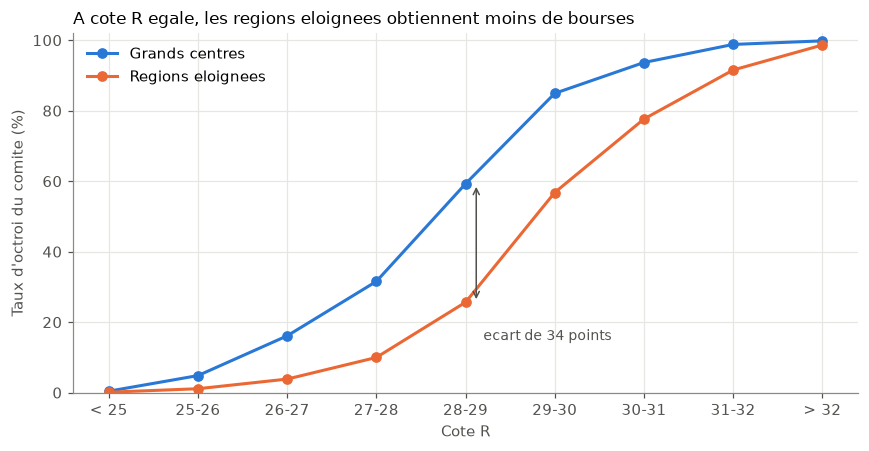

groupe,centres_%,eloignees_%,ecart_points,dossiers
< 25,0.4,0.1,0.3,1816
25-26,4.8,1.1,3.7,1009
26-27,16.1,3.8,12.3,1298
27-28,31.6,10.0,21.6,1261
28-29,59.3,25.6,33.7,1256
29-30,84.9,56.8,28.1,1092
30-31,93.7,77.6,16.1,882
31-32,98.8,91.5,7.3,618
> 32,99.8,98.6,1.2,768


In [3]:
bornes = [15, 25, 26, 27, 28, 29, 30, 31, 32, 40]
demandes['tranche_r'] = pd.cut(demandes['cote_r_equivalent'], bornes)
courbe = demandes.groupby(['tranche_r', 'groupe'], observed=True)['decision_octroi'].agg(['mean', 'size']).unstack()
etiquettes = [f'{int(i.left)}-{int(i.right)}' if i.right - i.left == 1 else (f'< {int(i.right)}' if i.left == 15 else f'> {int(i.left)}')
              for i in courbe.index]

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(courbe))
for g, nom in [('Centre', 'Grands centres'), ('Eloignee', 'Regions eloignees')]:
    y = courbe[('mean', g)].values
    ax.plot(x, y * 100, '-o', color=COULEURS[g], lw=2, ms=6, label=nom)
i = 4
ax.annotate('', xy=(x[i] + 0.12, courbe[('mean', 'Eloignee')].iloc[i] * 100),
            xytext=(x[i] + 0.12, courbe[('mean', 'Centre')].iloc[i] * 100),
            arrowprops=dict(arrowstyle='<->', color='#52514e', lw=1))
ecart_i = (courbe[('mean', 'Centre')].iloc[i] - courbe[('mean', 'Eloignee')].iloc[i]) * 100
ax.text(x[i] + 0.2, 16, f'ecart de {ecart_i:.0f} points', color='#52514e', fontsize=9, va='center')
ax.set_xticks(x, etiquettes)
ax.set_xlabel('Cote R')
ax.set_ylabel("Taux d'octroi du comite (%)")
ax.set_ylim(0, 102)
ax.set_title("A cote R egale, les regions eloignees obtiennent moins de bourses", loc='left', fontsize=11)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

table = courbe['mean'].mul(100).round(1).rename(columns={'Centre': 'centres_%', 'Eloignee': 'eloignees_%'})
table['ecart_points'] = (table['centres_%'] - table['eloignees_%']).round(1)
table['dossiers'] = courbe['size'].sum(axis=1).values
table.index = etiquettes
display(table)

Entre 28 et 29 de cote R, l'écart dépasse 30 points. Il n'est nul qu'aux extrêmes, là où
tout le monde est refusé (cote R < 25) ou accepté (cote R > 32).

## 4. Quelle part des 21 points est expliquée ?

On applique la règle que le comité utilise pour les **grands centres** aux candidats des
régions éloignées. Le résultat est le taux d'octroi que ces candidats auraient obtenu s'ils avaient
été jugés comme les autres. C'est une décomposition de type Oaxaca-Blinder (méthode de Fairlie)
adaptée à une décision oui/non :

- la différence entre les centres et ce taux contrefactuel est la part **expliquée** par les dossiers ;
- la différence entre ce taux contrefactuel et le taux réel est la part **inexpliquée**, c'est-à-dire
  le traitement différent.

In [4]:
variables = ['cote_r_equivalent', 'log_revenu', 'heures_travail_semaine', 'premiere_generation_universitaire']
centres, eloignees = demandes[demandes.eloignee == 0], demandes[demandes.eloignee == 1]

def taux_contrefactuel(colonnes):
    regle_centres = LogisticRegression(C=100, max_iter=5000).fit(centres[colonnes], centres['decision_octroi'])
    return regle_centres.predict_proba(eloignees[colonnes])[:, 1].mean()

contre_tout = taux_contrefactuel(variables)
contre_r = taux_contrefactuel(['cote_r_equivalent'])

decomposition = pd.DataFrame({
    'points': [ecart_brut, taux['Centre'] - contre_tout, contre_tout - taux['Eloignee']],
}, index=['ecart total', 'explique par le dossier', 'inexplique (traitement different)']).mul(100).round(1)
decomposition['part'] = (decomposition['points'] / decomposition['points'].iloc[0]).map('{:.0%}'.format)
display(decomposition)
print(f"Taux contrefactuel des regions eloignees : {contre_tout:.1%} (dossier complet), {contre_r:.1%} (cote R seule)")

,points,part
ecart total,21.1,100%
explique par le dossier,4.9,23%
inexplique (traitement different),16.1,76%


Taux contrefactuel des regions eloignees : 43.4% (dossier complet), 40.7% (cote R seule)


Si on regarde seulement la cote R, les régions éloignées auraient dû obtenir environ 41 % de
bourses. Avec tout le dossier, environ 43 %. Elles en ont obtenu 27 %. **Environ les trois quarts
de l'écart ne s'expliquent pas par les dossiers.**

## 5. Chiffrer la pénalité et la règle du comité

On modélise la décision du comité avec une régression logistique **lisible**. Pour comparer les
effets, on convertit chaque coefficient en **points de cote R** : combien de points de cote R il
faudrait ajouter pour compenser cet effet.

In [5]:
# La distance est exclue ici : elle est presque une copie de la region (section 6) et
# brouillerait la mesure de la penalite. Son effet est mesure a l'interieur des groupes plus bas.
colonnes = ['cote_r_equivalent', 'log_revenu', 'heures_travail_semaine',
            'premiere_generation_universitaire', 'eloignee']
regle = LogisticRegression(C=100, max_iter=5000).fit(demandes[colonnes], demandes['decision_octroi'])
coef = pd.Series(regle.coef_[0], index=colonnes)
point_r = coef['cote_r_equivalent']

resume = pd.DataFrame({'coefficient': coef, 'rapport_de_cotes': np.exp(coef), 'en_points_de_cote_R': coef / point_r})
resume.loc['log_revenu', 'en_points_de_cote_R'] = coef['log_revenu'] * np.log(2) / point_r
resume = resume.rename(index={'log_revenu': 'log_revenu (par doublement)'})
display(resume.round(3))

penalite_points = -coef['eloignee'] / point_r
poids_heures = coef['heures_travail_semaine'] / point_r
print(f'Penalite regionale : {penalite_points:.2f} point de cote R')
print(f'Une heure travaillee par semaine vaut {poids_heures:.3f} point de cote R')

,coefficient,rapport_de_cotes,en_points_de_cote_R
cote_r_equivalent,1.384,3.991,1.000
log_revenu (par doublement),1.780,5.931,0.891
heures_travail_semaine,0.201,1.223,0.146
premiere_generation_universitaire,-0.053,0.948,-0.038
eloignee,-1.933,0.145,-1.397


Penalite regionale : 1.40 point de cote R
Une heure travaillee par semaine vaut 0.146 point de cote R


Lecture :

- Venir d'une région éloignée divise les chances (en cotes) par environ 7 (rapport de cotes ≈ 0,14). C'est
  l'équivalent de **1,4 point de cote R** retiré.
- Un revenu familial deux fois plus élevé vaut environ 0,9 point de cote R. Le comité **avantage les
  familles aisées**.
- Chaque heure travaillée par semaine vaut environ 0,15 point de cote R. Le comité valorise les
  étudiants qui travaillent pendant leurs études.

### La règle est-elle la même dans chaque groupe ?

On ajuste le même modèle séparément sur les centres et sur les régions éloignées. Si une variable
n'a d'effet qu'**entre** les groupes et pas **à l'intérieur**, elle ne sert qu'à reconnaître la
région : c'est un proxy pur.

In [6]:
intra = {}
colonnes_intra = colonnes[:-1] + ['distance_domicile_campus_km']
for g, sous in demandes.groupby('groupe'):
    m = LogisticRegression(C=100, max_iter=5000).fit(sous[colonnes_intra], sous['decision_octroi'])
    c = pd.Series(m.coef_[0], index=colonnes_intra)
    intra[g] = c / c['cote_r_equivalent']
intra = pd.DataFrame(intra)
intra.loc['log_revenu'] *= np.log(2)
intra = intra.rename(index={'log_revenu': 'log_revenu (par doublement)'})
print('Effets en points de cote R, estimes a l\'interieur de chaque groupe')
display(intra.round(3))

numeriques = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine', 'distance_domicile_campus_km']
for g, sous in demandes.groupby('groupe'):
    corr = sous[numeriques].corr().abs().values
    print(f'{g:<9} plus forte correlation entre deux variables : {corr[np.triu_indices(len(numeriques), 1)].max():.3f}')

Effets en points de cote R, estimes a l'interieur de chaque groupe


,Centre,Eloignee
cote_r_equivalent,1.000,1.000
log_revenu (par doublement),0.881,0.900
heures_travail_semaine,0.156,0.135
premiere_generation_universitaire,-0.002,-0.087
distance_domicile_campus_km,0.004,0.001


Centre    plus forte correlation entre deux variables : 0.014
Eloignee  plus forte correlation entre deux variables : 0.015


Le comité applique **la même règle dans les deux groupes** : mêmes poids pour la cote R, le revenu
et les heures. La seule différence est le décalage de 1,4 point. La distance n'a aucun effet à
l'intérieur des groupes : c'est un proxy pur. Les petites différences sur les heures et la première
génération restent dans la marge d'erreur. Les variables sont aussi indépendantes entre elles à
l'intérieur de chaque groupe, donc ces effets ne se mélangent pas.

## 6. Les variables proxys

Une variable proxy permet de **deviner la région** sans la voir. On le mesure de deux façons :

- **AUC** : on entraîne un modèle qui prédit « région éloignée oui/non » à partir d'une seule
  variable, puis on mesure sa capacité à classer. 0,5 = la variable ne dit rien de la région ;
  1,0 = elle la révèle parfaitement. Les prédictions sont faites en validation croisée (5 plis),
  donc sur des dossiers que le modèle n'a pas vus.
- **Information mutuelle** : combien l'incertitude sur la région diminue quand on connaît la variable
  (0 = aucune information).

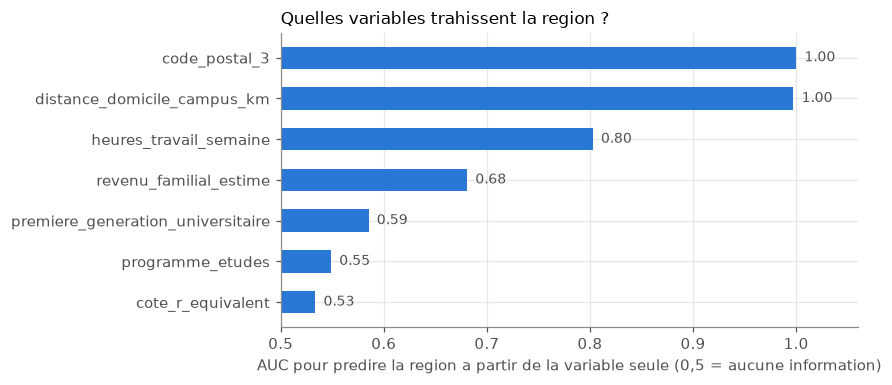

,AUC,information_mutuelle
variable,,
code_postal_3,1.000,0.702
distance_domicile_campus_km,0.997,0.629
heures_travail_semaine,0.803,0.153
revenu_familial_estime,0.681,0.064
premiere_generation_universitaire,0.585,0.030
programme_etudes,0.549,0.006
cote_r_equivalent,0.534,0.015


AUC combinee, sans region ni code postal : 0.998


AUC combinee, sans region, code postal ni distance : 0.840
Chaque code postal correspond a une seule region : True


In [7]:
autres = ['code_postal_3', 'distance_domicile_campus_km', 'heures_travail_semaine', 'revenu_familial_estime',
          'premiere_generation_universitaire', 'cote_r_equivalent', 'programme_etudes']
cible = demandes['eloignee']

def matrice(cols):
    return pd.get_dummies(demandes[cols], dtype=float)

def auc_cv(cols):
    proba = cross_val_predict(HistGradientBoostingClassifier(random_state=0), matrice(cols), cible,
                              cv=5, method='predict_proba')[:, 1]
    return roc_auc_score(cible, proba)

lignes = []
for col in autres:
    categorielle = not pd.api.types.is_numeric_dtype(demandes[col])
    X = matrice([col])
    mi = mutual_info_classif(X, cible, discrete_features=categorielle, random_state=0).sum()
    lignes.append({'variable': col, 'AUC': auc_cv([col]), 'information_mutuelle': mi})
proxys = pd.DataFrame(lignes).set_index('variable').sort_values('AUC')

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(proxys.index, proxys['AUC'] - 0.5, left=0.5, color=CENTRE, height=0.55)
for i, v in enumerate(proxys['AUC']):
    ax.text(v + 0.008, i, f'{v:.2f}', va='center', fontsize=9, color='#52514e')
ax.axvline(0.5, color='#8a8984', lw=1)
ax.set_xlim(0.5, 1.06)
ax.set_xlabel("AUC pour predire la region a partir de la variable seule (0,5 = aucune information)")
ax.set_title('Quelles variables trahissent la region ?', loc='left', fontsize=11)
plt.tight_layout()
plt.show()
display(proxys.sort_values('AUC', ascending=False).round(3))

sans_cp = ['distance_domicile_campus_km', 'heures_travail_semaine', 'revenu_familial_estime',
           'premiere_generation_universitaire', 'cote_r_equivalent', 'programme_etudes']
print(f'AUC combinee, sans region ni code postal : {auc_cv(sans_cp):.3f}')
print(f'AUC combinee, sans region, code postal ni distance : {auc_cv([c for c in sans_cp if c != "distance_domicile_campus_km"]):.3f}')
print(f'Chaque code postal correspond a une seule region : {demandes.groupby("code_postal_3")["region_administrative"].nunique().max() == 1}')

**Ce que l'on fait de chaque proxy :**

| Variable | AUC | Effet sur la décision, à région égale | Décision |
|---|---|---|---|
| `code_postal_3` | 1,00 | copie exacte de la région | **exclue** du modèle |
| `distance_domicile_campus_km` | 1,00 | aucun | **exclue** : proxy pur |
| `heures_travail_semaine` | 0,80 | positif, identique dans les deux groupes | **conservée** : travailler pendant ses études est un mérite légitime |
| `revenu_familial_estime` | 0,68 | positif : avantage les familles aisées | **neutralisée** : critère inéquitable pour une bourse, et proxy |
| `premiere_generation_universitaire` | 0,59 | nul | conservée, sans effet |
| `cote_r_equivalent` | 0,53 | critère principal | conservée |
| `programme_etudes` | 0,55 | négligeable | conservée |

Être un proxy ne suffit pas pour exclure une variable. Les heures travaillées révèlent en partie
la région, mais elles mesurent aussi un effort réel. Les retirer pénaliserait justement les étudiants
des régions, qui travaillent plus. C'est un **choix éthique assumé**, documenté ici.

C'est aussi pour ça que **supprimer la colonne région ne suffit pas** : avec le code postal ou la
distance, n'importe quel modèle la reconstruit presque parfaitement.

## 7. Audit du modèle en production

On reproduit la forêt aléatoire du carnet `baseline_model.ipynb`, avec les mêmes paramètres et le même découpage.

In [8]:
CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']
brut = pd.read_csv('data/donnees_demandes.csv')
brut_cand = pd.read_csv('data/candidats_evaluation.csv')

def encoder(df_entrainement, df_cible, exclues=()):
    X = pd.get_dummies(df_entrainement.drop(columns=['id_candidat', 'decision_octroi'], errors='ignore'), columns=CATEGORIELLES)
    Xc = pd.get_dummies(df_cible.drop(columns=['id_candidat', 'decision_octroi'], errors='ignore'), columns=CATEGORIELLES)
    X = X[[c for c in X.columns if not c.startswith(tuple(exclues))]] if exclues else X
    return X, Xc.reindex(columns=X.columns, fill_value=0)

def foret():
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)

train, test = train_test_split(brut, test_size=0.3, random_state=42, stratify=brut['decision_octroi'])
groupe_test = np.where(test['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')
X_train, X_test = encoder(train, test)
pred_test = foret().fit(X_train, train['decision_octroi']).predict(X_test)

cadre = MetricFrame(metrics={'exactitude': accuracy_score, 'taux_selection': selection_rate,
                             'TPR_vs_comite': true_positive_rate},
                    y_true=test['decision_octroi'], y_pred=pred_test, sensitive_features=groupe_test)
display(cadre.by_group.round(3))
print(f"Exactitude globale contre le comite : {accuracy_score(test['decision_octroi'], pred_test):.1%}")

print('\nRetirer les colonnes sensibles ne ferme pas l\'ecart :')
for exclues, nom in [((), 'toutes les colonnes'), (('region_administrative_',), 'sans region'),
                     (('region_administrative_', 'code_postal_3_'), 'sans region ni code postal')]:
    Xa, Xb = encoder(train, test, exclues)
    p = foret().fit(Xa, train['decision_octroi']).predict(Xb)
    ecart = p[groupe_test == 'Centre'].mean() - p[groupe_test == 'Eloignee'].mean()
    print(f'  {nom:<28} ecart de taux de selection {ecart:.3f}')

,exactitude,taux_selection,TPR_vs_comite
sensitive_feature_0,,,
Centre,0.878,0.459,0.847
Eloignee,0.887,0.271,0.785


Exactitude globale contre le comite : 88.1%

Retirer les colonnes sensibles ne ferme pas l'ecart :


  toutes les colonnes          ecart de taux de selection 0.188


  sans region                  ecart de taux de selection 0.180


  sans region ni code postal   ecart de taux de selection 0.173


Contre `decision_octroi`, l'écart de TPR n'est que de 0,06, alors que l'écart de taux de sélection
atteint 0,19. **Ce n'est pas un signe d'équité** : cela montre seulement que la forêt reproduit
fidèlement le comité, biais compris.
Pour mesurer l'égalité des chances, il faut savoir qui *mérite* la bourse, et les décisions du comité
ne peuvent pas servir de référence.

## 8. Quelle métrique d'équité ?

| | Parité démographique | **Égalité des chances (retenue)** |
|---|---|---|
| Question | Chaque groupe reçoit-il le même pourcentage de bourses ? | Parmi ceux qui méritent la bourse, chaque groupe a-t-il la même chance de l'obtenir ? |
| Tient compte du mérite | Non | Oui |
| Risque | Accorder des quotas, refuser des candidats plus méritants | Dépend de la définition du mérite |

**Pourquoi l'égalité des chances.** Une bourse d'excellence récompense un mérite. Si les dossiers
des régions sont en moyenne un peu plus faibles, la parité démographique imposerait de les
compenser par un quota, ce qui serait injuste envers des candidats plus forts. L'égalité des chances
demande seulement qu'à mérite égal, la chance soit égale. C'est aussi la métrique retenue par le
correcteur automatique.

**Sa faiblesse, et comment on la traite.** L'égalité des chances dépend de la définition du mérite.
Si on définit le mérite par les décisions du comité, on valide son biais (section 7). On reconstruit
donc le mérite **sans** la pénalité régionale et **sans** l'avantage de revenu.

**Les deux métriques ne peuvent pas être satisfaites ensemble** quand les groupes ont des profils
différents (Kleinberg et al., 2016 ; Chouldechova, 2017). On rapporte quand même la parité
démographique et le ratio des 4/5 (section 10) comme indicateurs secondaires.

## 9. Valider sans connaître l'étalon

L'étalon du jury est caché. On teste une hypothèse : **le mérite = cote R + 0,145 × heures
travaillées**, c'est-à-dire la règle du comité sans pénalité régionale et sans avantage de revenu.
On ajoute un peu de hasard à cette règle (écart-type σ, en points de cote R), car un étalon réel n'est
jamais parfaitement prévisible. On regarde ensuite si l'hypothèse reproduit les chiffres connus :

- l'écart d'égalité des chances du modèle en production, que le jury chiffre à **0,270** ;
- l'exactitude de notre soumission sur HxBuddy, **94,73 %**.

In [9]:
X_hist, X_cand = encoder(brut, brut_cand)
pred_production = foret().fit(X_hist, brut['decision_octroi']).predict(X_cand)

modele = modele_comite().fit(demandes, demandes['decision_octroi'])
pred_corrige = octroyer(score_sans_biais(modele, candidats, demandes['log_revenu'].median()), 0.40)

eloigne = candidats['eloignee'].values == 1
merite = candidats['cote_r_equivalent'] + poids_heures * candidats['heures_travail_semaine']

def ecart_egalite_chances(reference, pred):
    tpr = lambda masque: pred[masque & (reference == 1)].mean()
    return tpr(~eloigne) - tpr(eloigne)

rng = np.random.default_rng(42)
lignes = []
for sigma in [0.0, 0.25, 0.5, 0.75, 1.0]:
    for _ in range(50):
        z = merite + rng.normal(0, sigma, len(merite))
        reference = (z >= np.quantile(z, 0.6)).astype(int).values
        lignes.append({'sigma': sigma,
                       'exactitude_corrige': (pred_corrige == reference).mean(),
                       'exactitude_production': (pred_production == reference).mean(),
                       'ecart_EC_production': ecart_egalite_chances(reference, pred_production),
                       'ecart_EC_corrige': ecart_egalite_chances(reference, pred_corrige)})
simulation = pd.DataFrame(lignes).groupby('sigma').mean()
display(simulation.round(3))

,exactitude_corrige,exactitude_production,ecart_EC_production,ecart_EC_corrige
sigma,,,,
0.00,0.994,0.903,0.296,-0.002
0.25,0.975,0.901,0.295,-0.003
0.50,0.951,0.894,0.283,-0.009
0.75,0.927,0.882,0.275,-0.006
1.00,0.904,0.867,0.270,-0.001


Avec un hasard modéré (σ ≈ 0,5 point de cote R), la simulation reproduit **les deux chiffres
connus** : notre exactitude tombe autour de 95 % (94,73 % observé) et l'écart du modèle en
production autour de 0,28 (0,270 annoncé). Ce n'est pas une preuve, mais c'est une forte cohérence.

Dans cette simulation, notre modèle ramène l'écart d'égalité des chances **près de 0**.

### Ce que disent les scores HxBuddy

Quatre soumissions ont servi à trancher entre des hypothèses. On n'a pas réglé d'hyperparamètres
sur le classement.

| Soumission | Exactitude | Conclusion |
|---|---|---|
| Région neutralisée | 92,73 % | point de départ |
| Cote R seule | 92,18 % | l'étalon ne se limite pas à la cote R |
| Région **et revenu** neutralisés | **94,73 %** | l'étalon ignore le revenu familial |
| Région et heures neutralisées | 90,13 % | l'étalon tient compte des heures travaillées |

## 10. Avant / après, sur les 4 000 candidats à évaluer

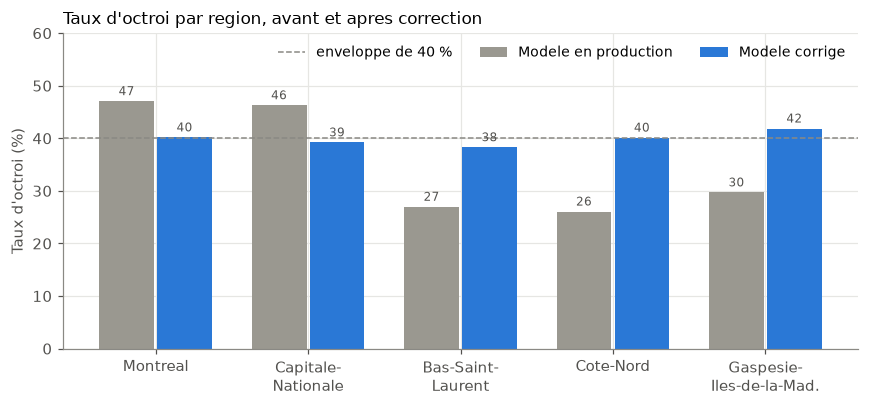

,production,corrige
taux d'octroi global,0.390,0.400
taux centres,0.468,0.398
taux eloignees,0.278,0.402
ecart de parite demographique,0.190,-0.004
ratio des 4/5 (eloignees / centres),0.593,1.010


In [10]:
comparaison = pd.DataFrame({
    'region': candidats['region_administrative'],
    'production': pred_production,
    'corrige': pred_corrige,
}).groupby('region').mean().loc[['Montreal', 'Capitale-Nationale', 'Bas-Saint-Laurent', 'Cote-Nord',
                                 'Gaspesie-Iles-de-la-Madeleine']]

fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(comparaison))
larg = 0.36
for decalage, col, couleur, nom in [(-larg / 2 - 0.01, 'production', NEUTRE, 'Modele en production'),
                                    (larg / 2 + 0.01, 'corrige', CENTRE, 'Modele corrige')]:
    barres = ax.bar(x + decalage, comparaison[col] * 100, larg, color=couleur, label=nom)
    ax.bar_label(barres, fmt='%.0f', fontsize=8, color='#52514e', padding=2)
ax.axhline(40, color='#8a8984', lw=1, ls='--', label='enveloppe de 40 %')
ax.set_xticks(x, ['Montreal', 'Capitale-\nNationale', 'Bas-Saint-\nLaurent', 'Cote-Nord', 'Gaspesie-\nIles-de-la-Mad.'])
ax.set_ylabel("Taux d'octroi (%)")
ax.set_ylim(0, 60)
ax.set_title("Taux d'octroi par region, avant et apres correction", loc='left', fontsize=11)
ax.legend(frameon=False, loc='upper right', ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

def indicateurs(pred):
    c, e = pred[~eloigne].mean(), pred[eloigne].mean()
    return {"taux d'octroi global": pred.mean(), 'taux centres': c, 'taux eloignees': e,
            'ecart de parite demographique': c - e, 'ratio des 4/5 (eloignees / centres)': e / c}

display(pd.DataFrame({'production': indicateurs(pred_production), 'corrige': indicateurs(pred_corrige)}).round(3))

- Le modèle corrigé respecte l'enveloppe (40,0 %).
- Le taux d'octroi est maintenant presque identique entre les deux groupes. **On n'a imposé aucun
  quota** : cette égalité vient d'elle-même une fois le biais retiré. Les candidats des régions ont une
  cote R un peu plus basse, mais ils travaillent environ 4 heures de plus par semaine, et ces deux effets
  s'équilibrent presque.
- Le ratio des 4/5 passe d'environ 0,6 (sous le seuil usuel de 0,8) à environ 1.

## 11. Conclusions et limites

**Conclusions**

- Le comité applique une pénalité d'environ 1,4 point de cote R aux régions éloignées. Elle explique
  environ trois quarts de l'écart de 21 points.
- Il avantage aussi les familles aisées, ce qui creuse encore l'écart régional.
- Le modèle en production reproduit fidèlement ces deux biais. Ses 88 % d'exactitude mesurent sa
  fidélité au comité, pas sa justesse.
- Retirer la région ne suffit pas : le code postal et la distance la révèlent parfaitement.

**Limites**

- L'étalon est inconnu. Notre définition du mérite repose sur des hypothèses (section 9), cohérentes
  avec les chiffres publiés et avec les scores HxBuddy.
- Garder les heures travaillées est un choix éthique, pas un fait technique. Un autre comité pourrait
  le trancher autrement.
- Les données sont synthétiques et ne comptent que cinq régions. Un vrai déploiement demanderait un audit
  par région et par sous-groupe (première génération, programme), ainsi qu'un suivi en production.